In [7]:
import pandas as pd

# Load the Excel file
filepath = "results\\predicts.xlsx"
xls = pd.ExcelFile(filepath)

# Get the sheet names
sheet_names = xls.sheet_names


In [6]:
import pycm
def getcms(filepath, sheet):
    df = pd.read_excel(filepath, sheet_name=sheet, header=None)
    truelabel = df.iloc[0, 1:].values.astype(int)
    results = {}
    acc_lows = {}
    acc_ups = {}
    for model_idx in range(1, len(df)):
        # 获取模型名称和预测结果
        
        model_name = df.iloc[model_idx, 0]
        predictions = df.iloc[model_idx, 1:].values.astype(int)
        cm = pycm.ConfusionMatrix(actual_vector=truelabel, predict_vector=predictions,digit=4)
        results[model_name] = cm
        (acc_low, acc_up) = cm.CI95
        acc_lows[model_name] = acc_low
        acc_ups[model_name] = acc_up
        cm.save_csv(f"deepseek\\{model_name}_sub{sheet}")
    return results, acc_lows, acc_ups


In [8]:
from sklearn.metrics import confusion_matrix
from scipy.stats import binom
import pandas as pd
import numpy as np

acc_lows_all = {}
acc_ups_all = {}
cms_all = {}
for sheet in sheet_names:
    cms, acc_lows, acc_ups = getcms(filepath, sheet)
    acc_lows_all[sheet] = acc_lows
    acc_ups_all[sheet] = acc_ups
    cms_all[sheet] = cms

    


# 示例输出


In [ ]:
mean_lows = {}
mean_ups = {}
after_mean_lows = {}
after_mean_ups = {}
ACCs_all = {}
matrixs_all = {}
for model in cms_all[sheet_names[0]].keys():
    mean_low =[]
    mean_up = []
    ACCs = []
    matrixs = []
    for sheet in sheet_names:
        matrixs.append(cms_all[sheet][model].matrix)
        mean_low.append(round(acc_lows_all[sheet][model] * 100, 2))
        mean_up.append(round(acc_ups_all[sheet][model] * 100, 2))
        ACCs.append(round(cms_all[sheet][model].Overall_ACC * 100, 2))
    ACCs.append(round(np.mean(ACCs), 2))
    matrixs_all[model] = matrixs
    ACCs_all[model] = ACCs
    mean_lows[model] = mean_low
    mean_ups[model] = mean_up
    after_mean_low = round(np.mean(mean_low), 2)
    after_mean_up = round(np.mean(mean_up), 2)

    after_mean_lows[model] = after_mean_low
    after_mean_ups[model] = after_mean_up
    



In [42]:
labels = matrixs_all[model][0].keys()
tr_labels = ["lefthand", "righthand", "tongue", "feet"]

In [15]:
matrixs_all[model][0]

{0: {0: 68, 1: 0, 2: 2, 3: 2},
 1: {0: 5, 1: 67, 2: 0, 3: 0},
 2: {0: 2, 1: 0, 2: 51, 3: 19},
 3: {0: 0, 1: 1, 2: 10, 3: 61}}

In [44]:
summatrixs_all = {}
for model in matrixs_all.keys():
    summatrixs_model = {}
    for i in labels:
        summatrixs_model[tr_labels[i]] = {}
        for j in labels:
            summatrixs = []
            for k in range(9):
                summatrixs.append(matrixs_all[model][k][i][j])
            summatrixs_model[tr_labels[i]][tr_labels[j]] = sum(summatrixs)
    summatrixs_all[model] = summatrixs_model

print(summatrixs_all[model])



{'lefthand': {'lefthand': 509, 'righthand': 60, 'tongue': 39, 'feet': 40}, 'righthand': {'lefthand': 110, 'righthand': 468, 'tongue': 34, 'feet': 36}, 'tongue': {'lefthand': 48, 'righthand': 52, 'tongue': 454, 'feet': 94}, 'feet': {'lefthand': 61, 'righthand': 45, 'tongue': 56, 'feet': 486}}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from pycm import ConfusionMatrix
def plot_confusion_matrix(cm,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function modified to plots the ConfusionMatrix object.
    Normalization can be applied by setting `normalize=True`.
    
    Code Reference : 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    
    """

    plt_cm = []
    for i in cm.classes :
        row=[]
        for j in cm.classes:
            row.append(cm.table[i][j])
        plt_cm.append(row)
    plt_cm = np.array(plt_cm)
    if normalize:
        plt_cm = plt_cm.astype('float') / plt_cm.sum(axis=1)[:, np.newaxis]     
    plt.imshow(plt_cm, interpolation='nearest', cmap=cmap,vmin=0, vmax = 600)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(cm.classes))
    plt.xticks(tick_marks, cm.classes)
    plt.yticks(tick_marks, cm.classes)

    fmt = '.2f' if normalize else 'd'
    thresh = plt_cm.max() / 2.
    for i, j in itertools.product(range(plt_cm.shape[0]), range(plt_cm.shape[1])):
        plt.text(j, i, format(plt_cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if plt_cm[i, j] > thresh else "black",
                 fontsize = 18)

    plt.tight_layout()
    plt.ylabel('Actual')
    plt.xlabel('Predict')

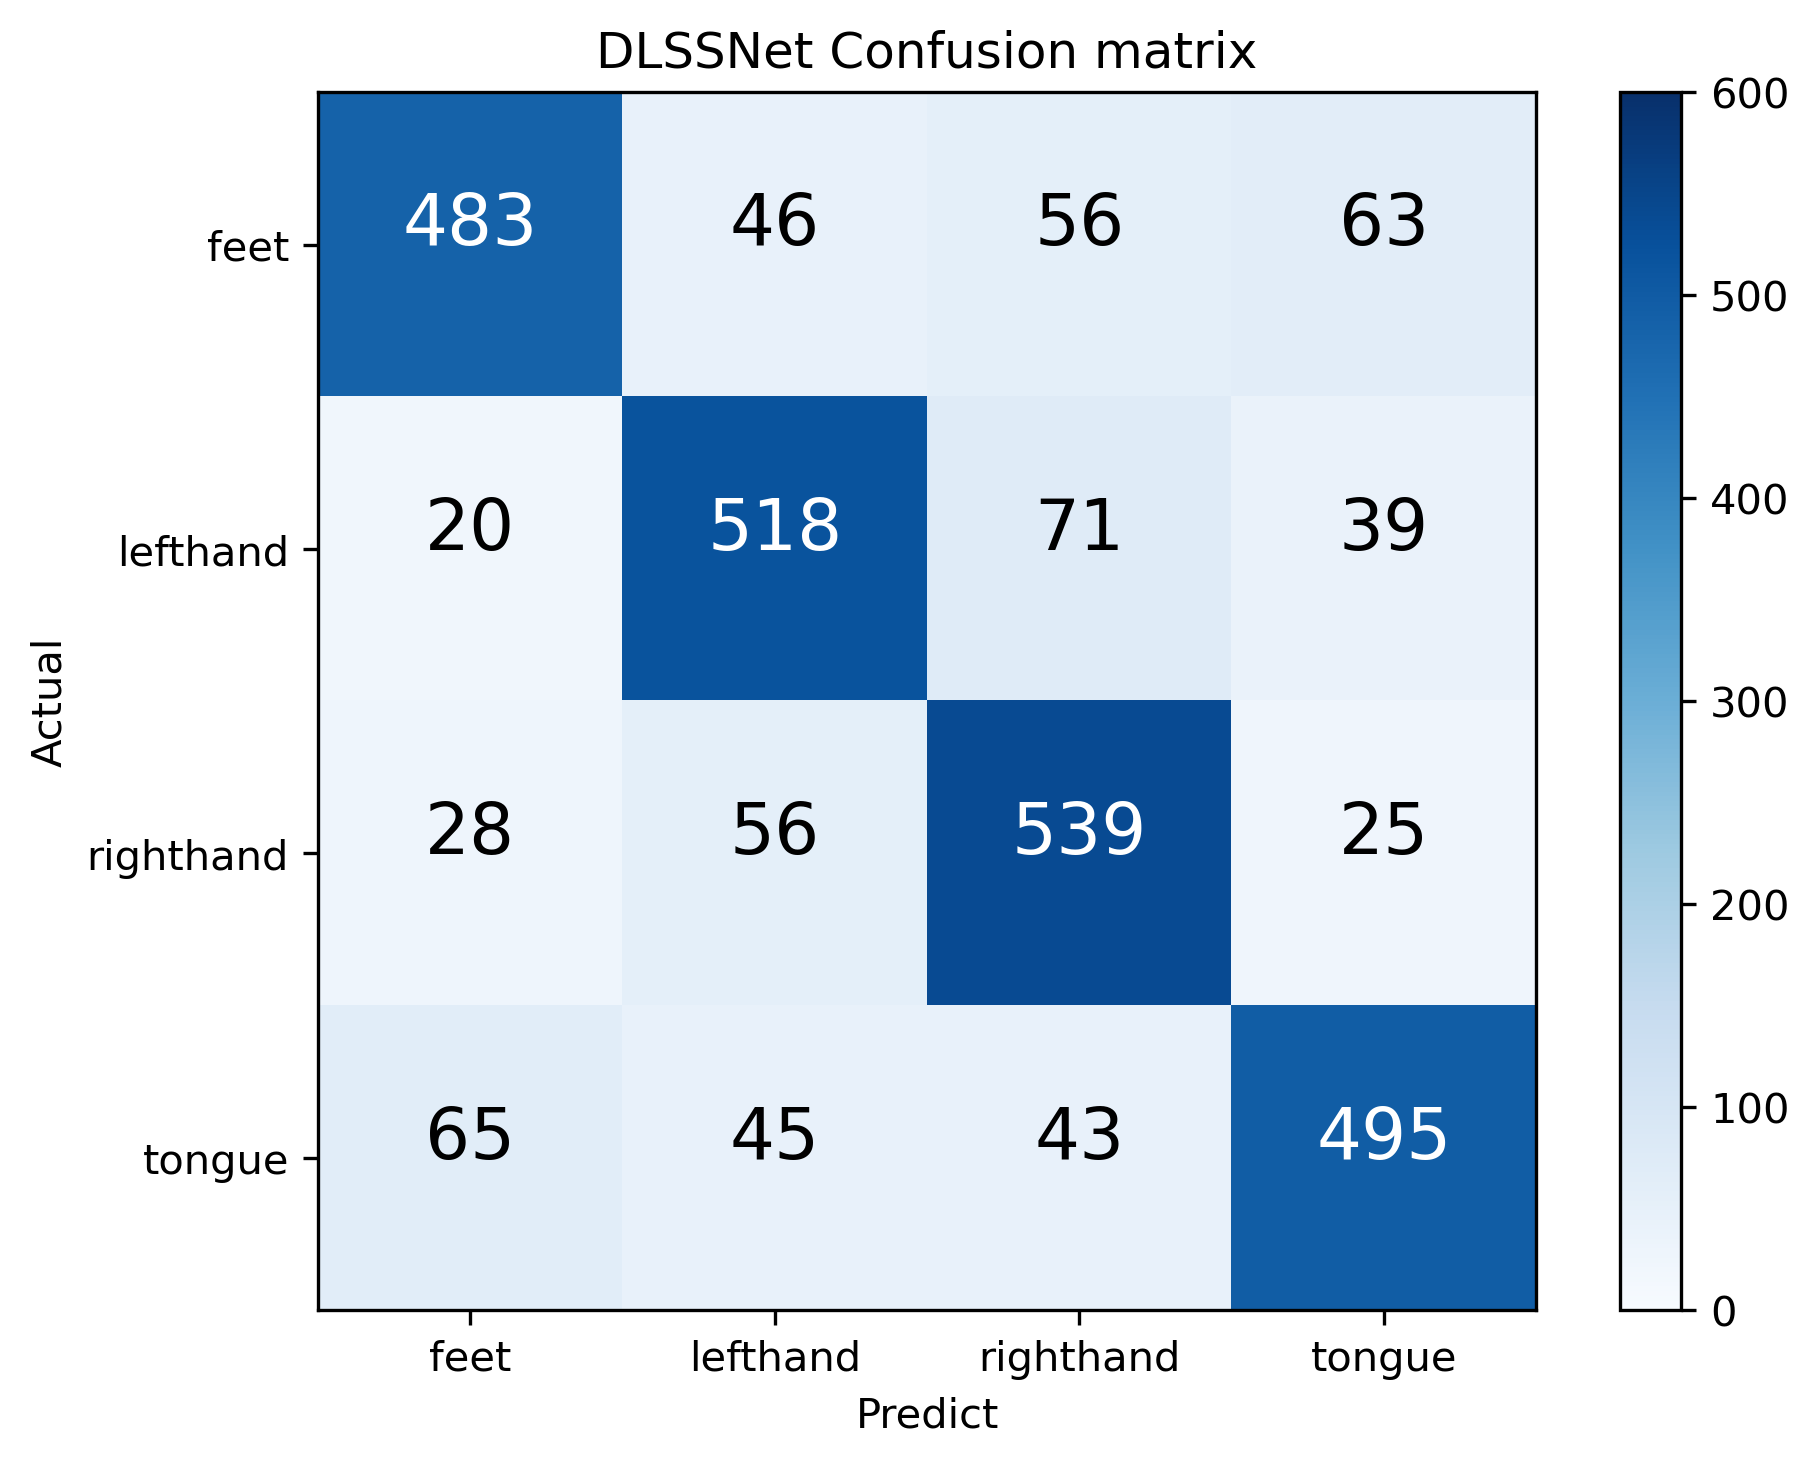

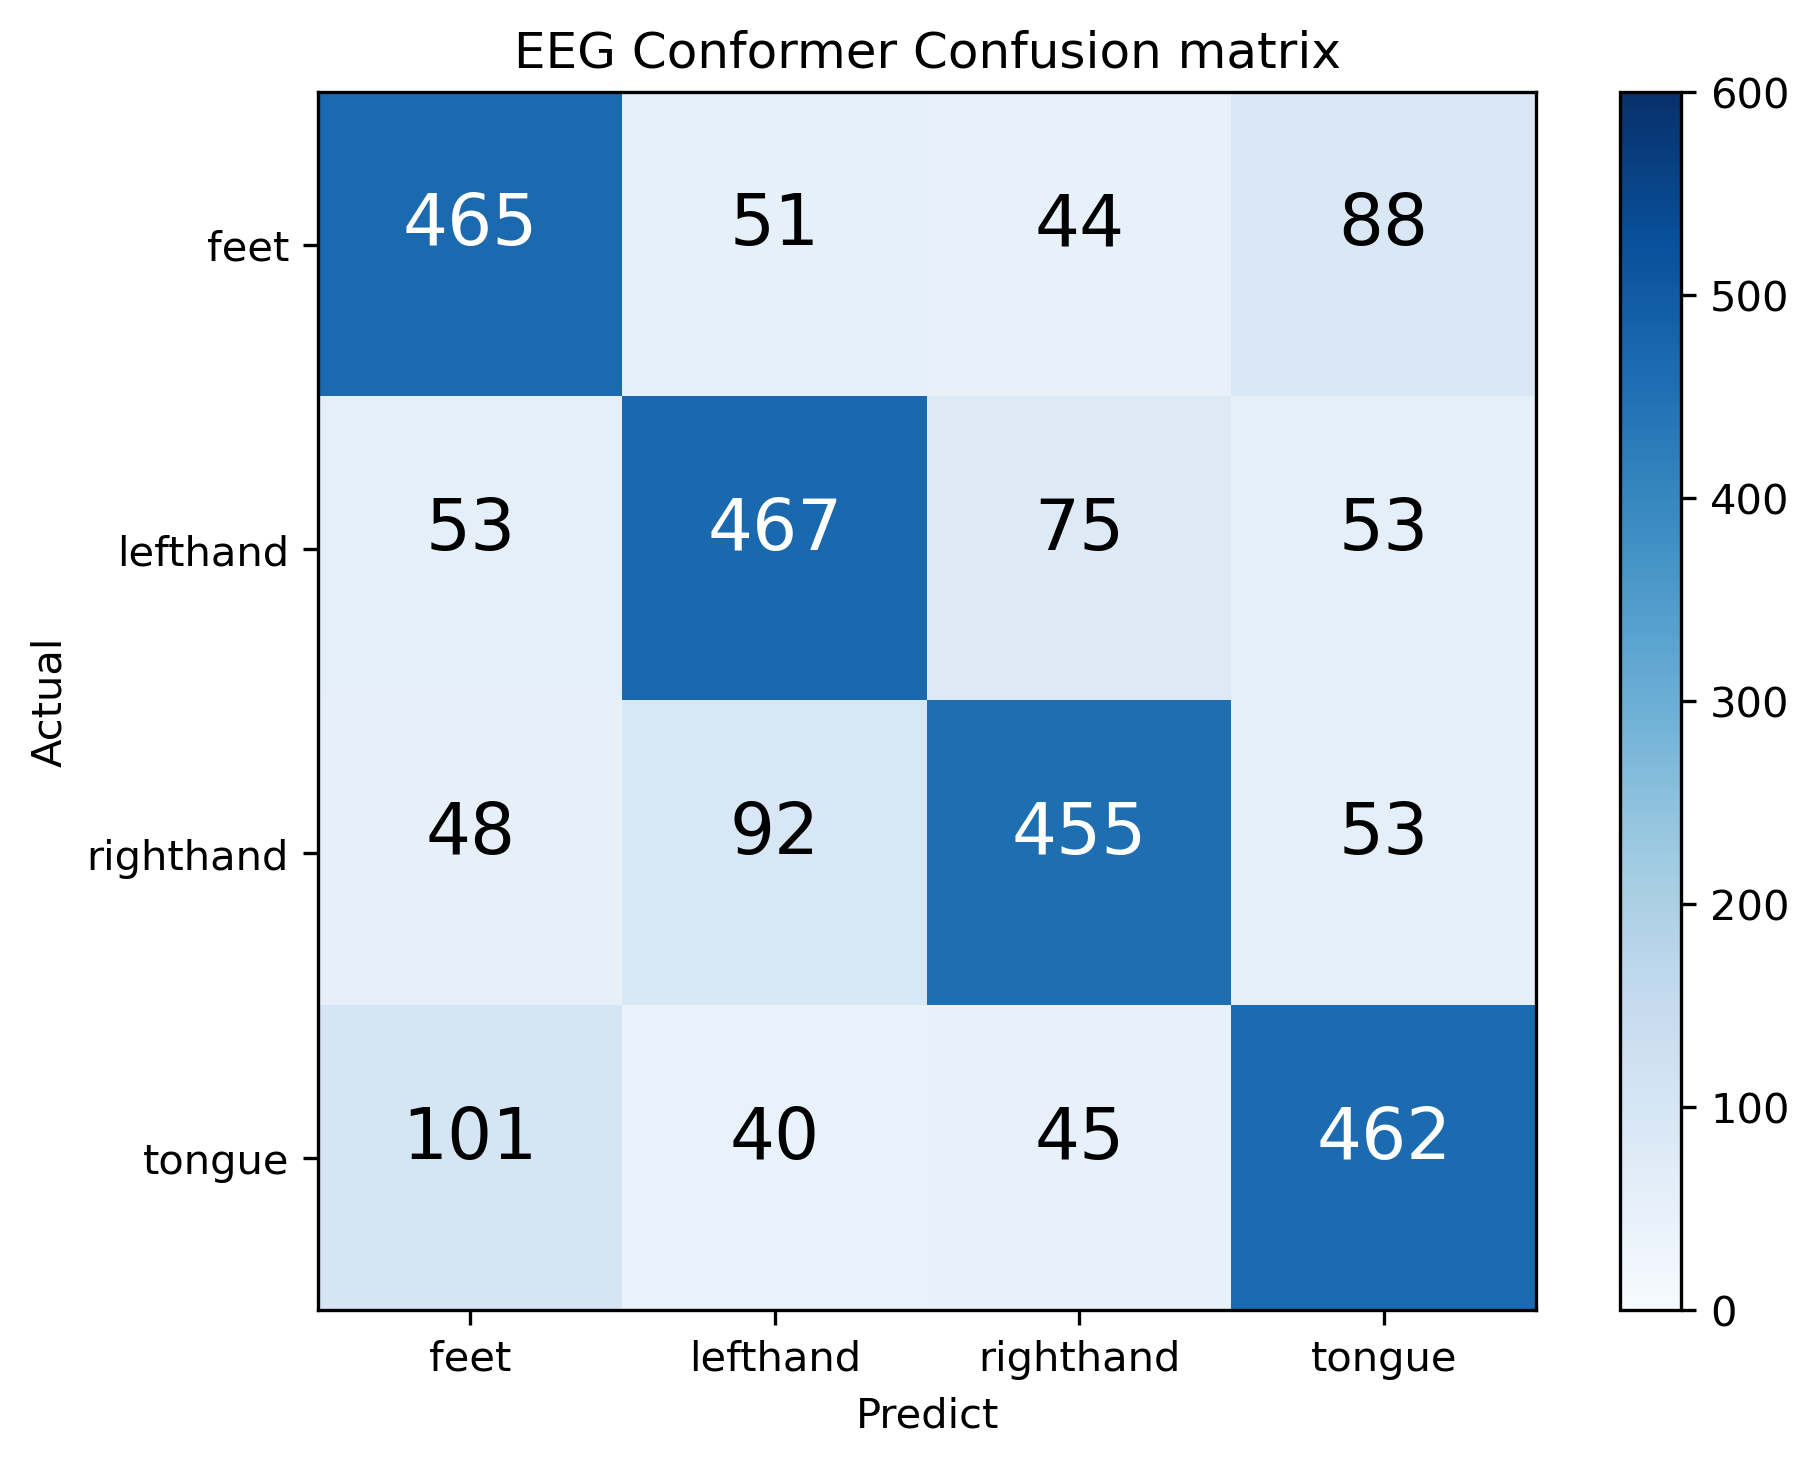

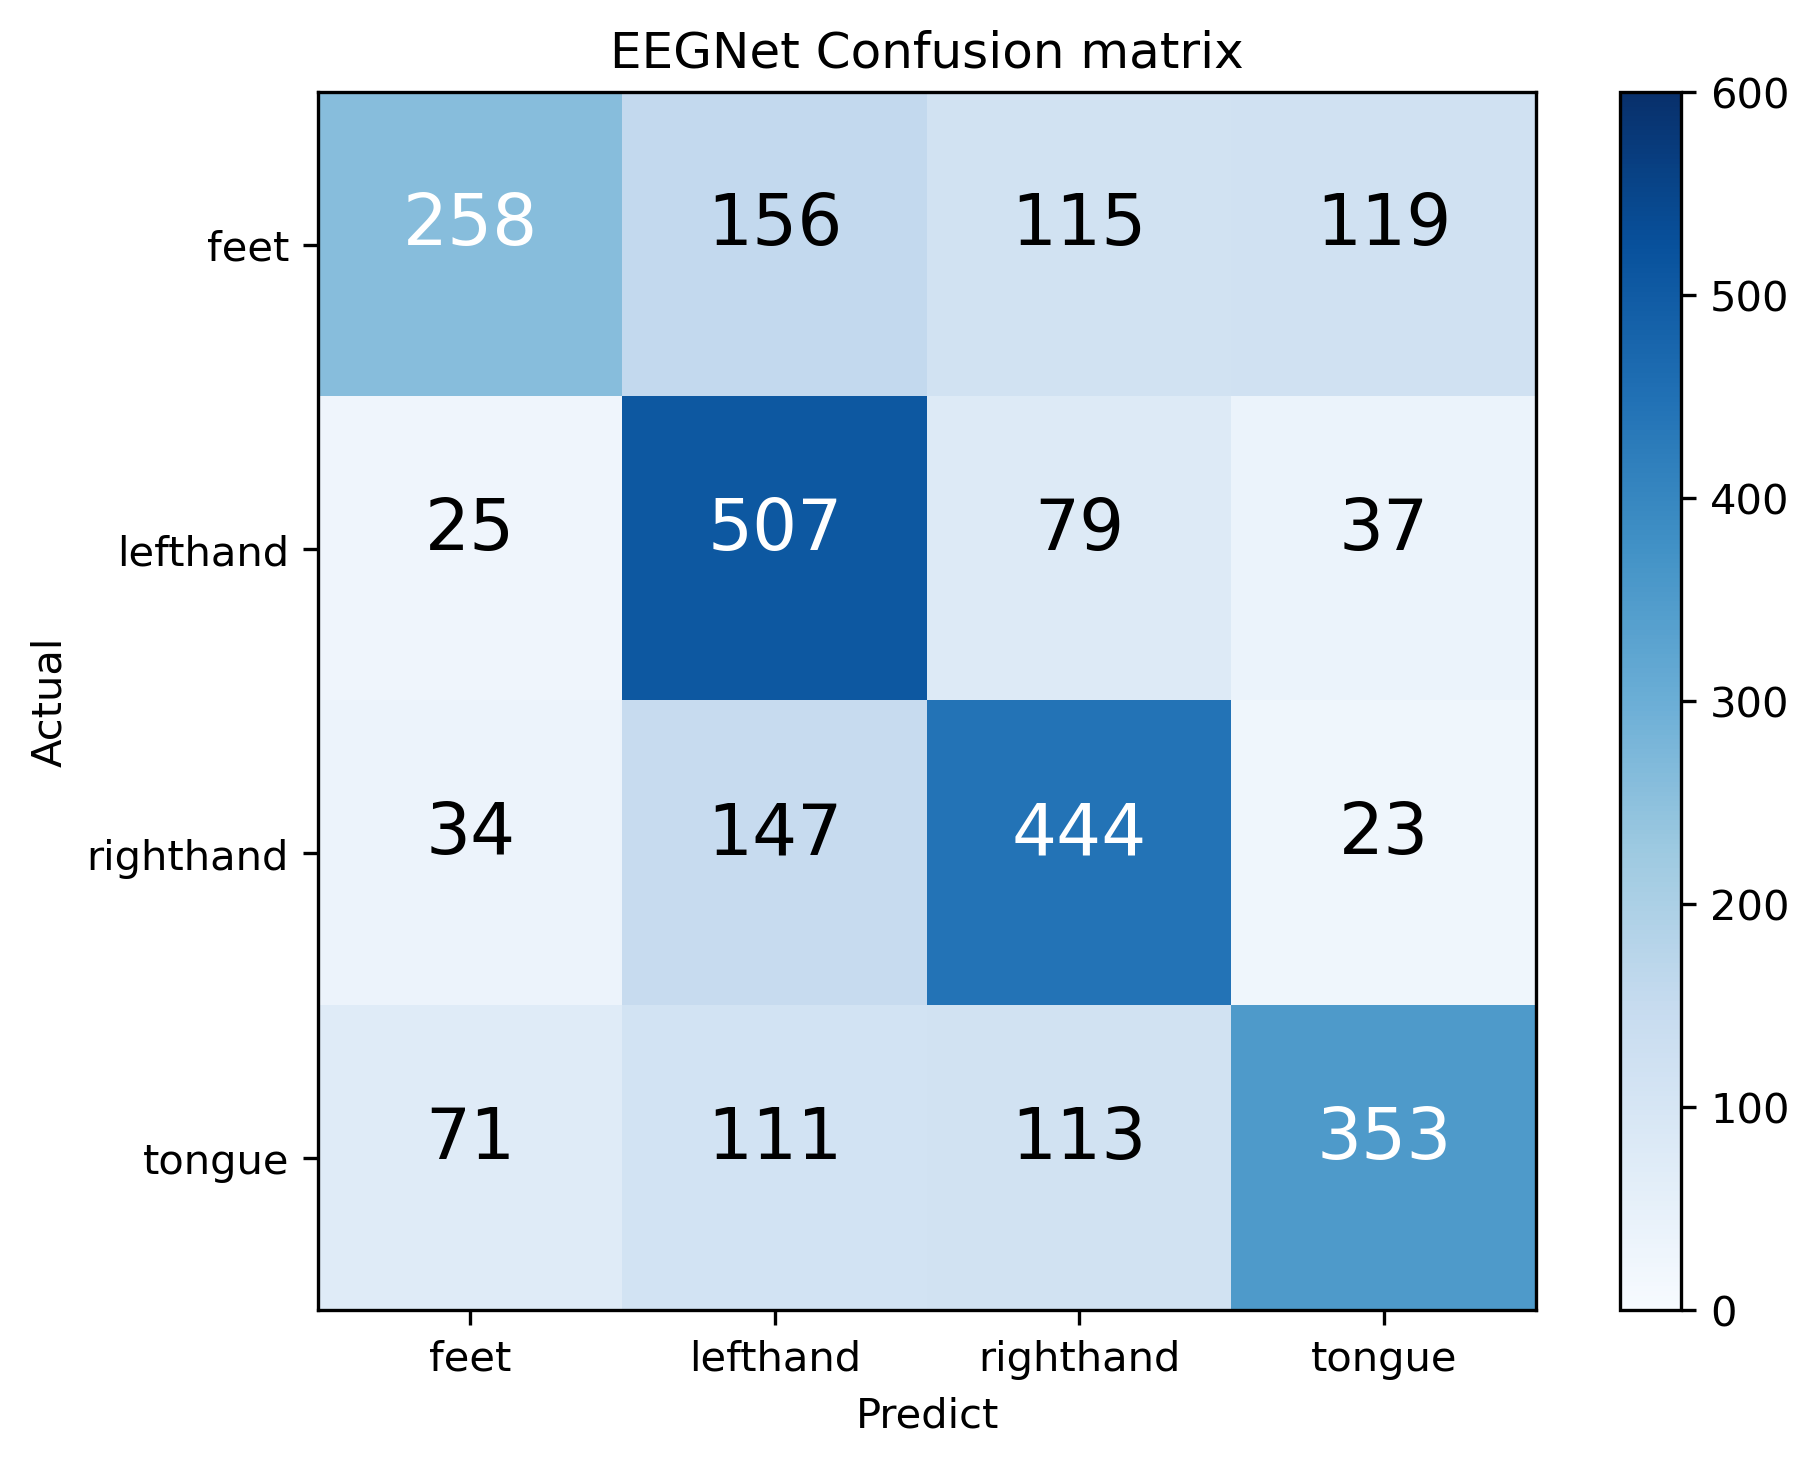

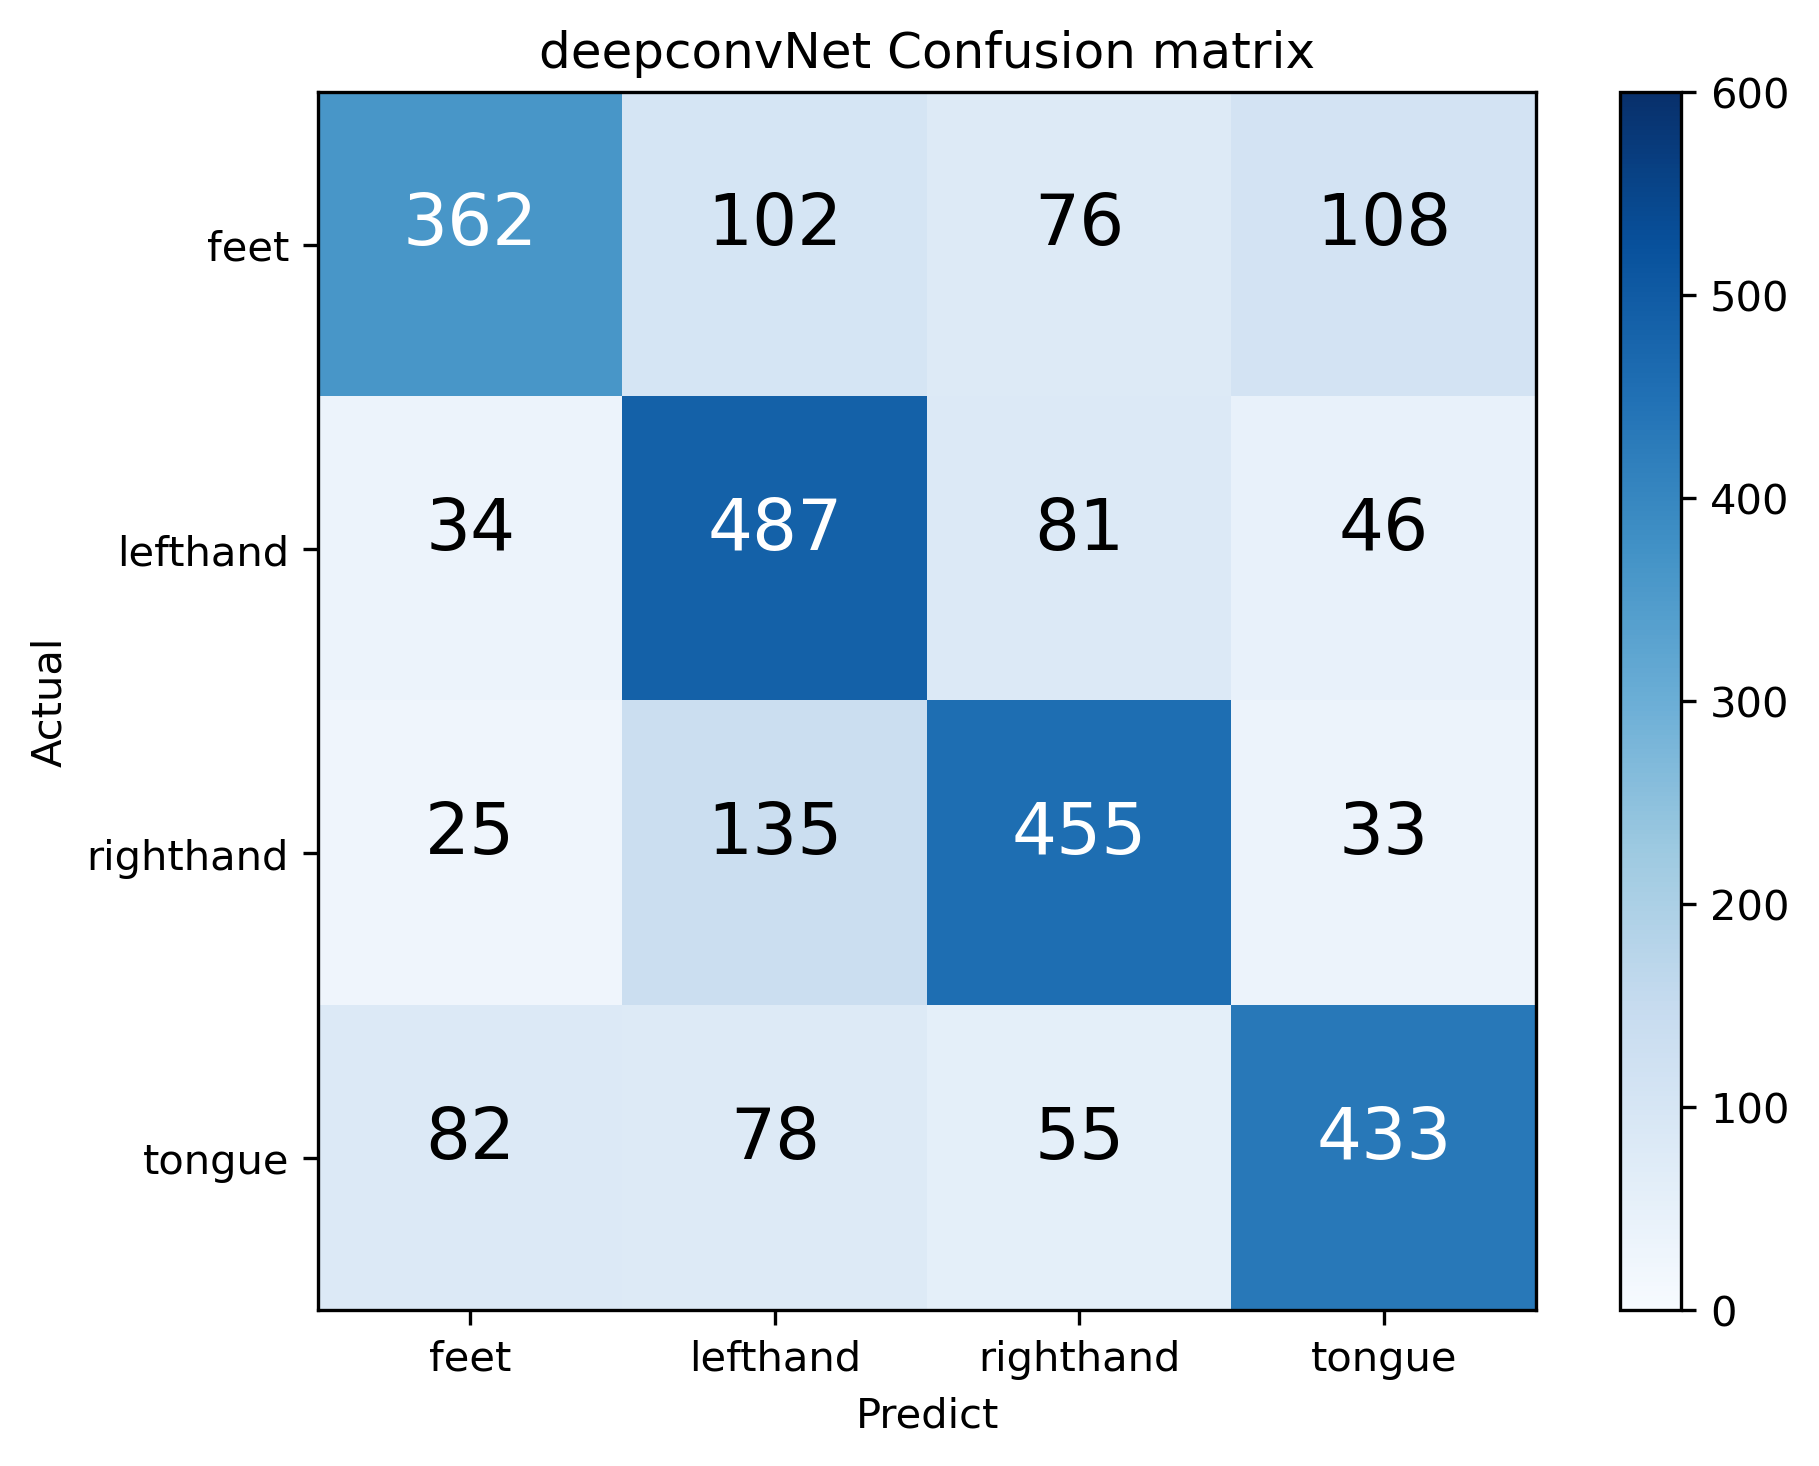

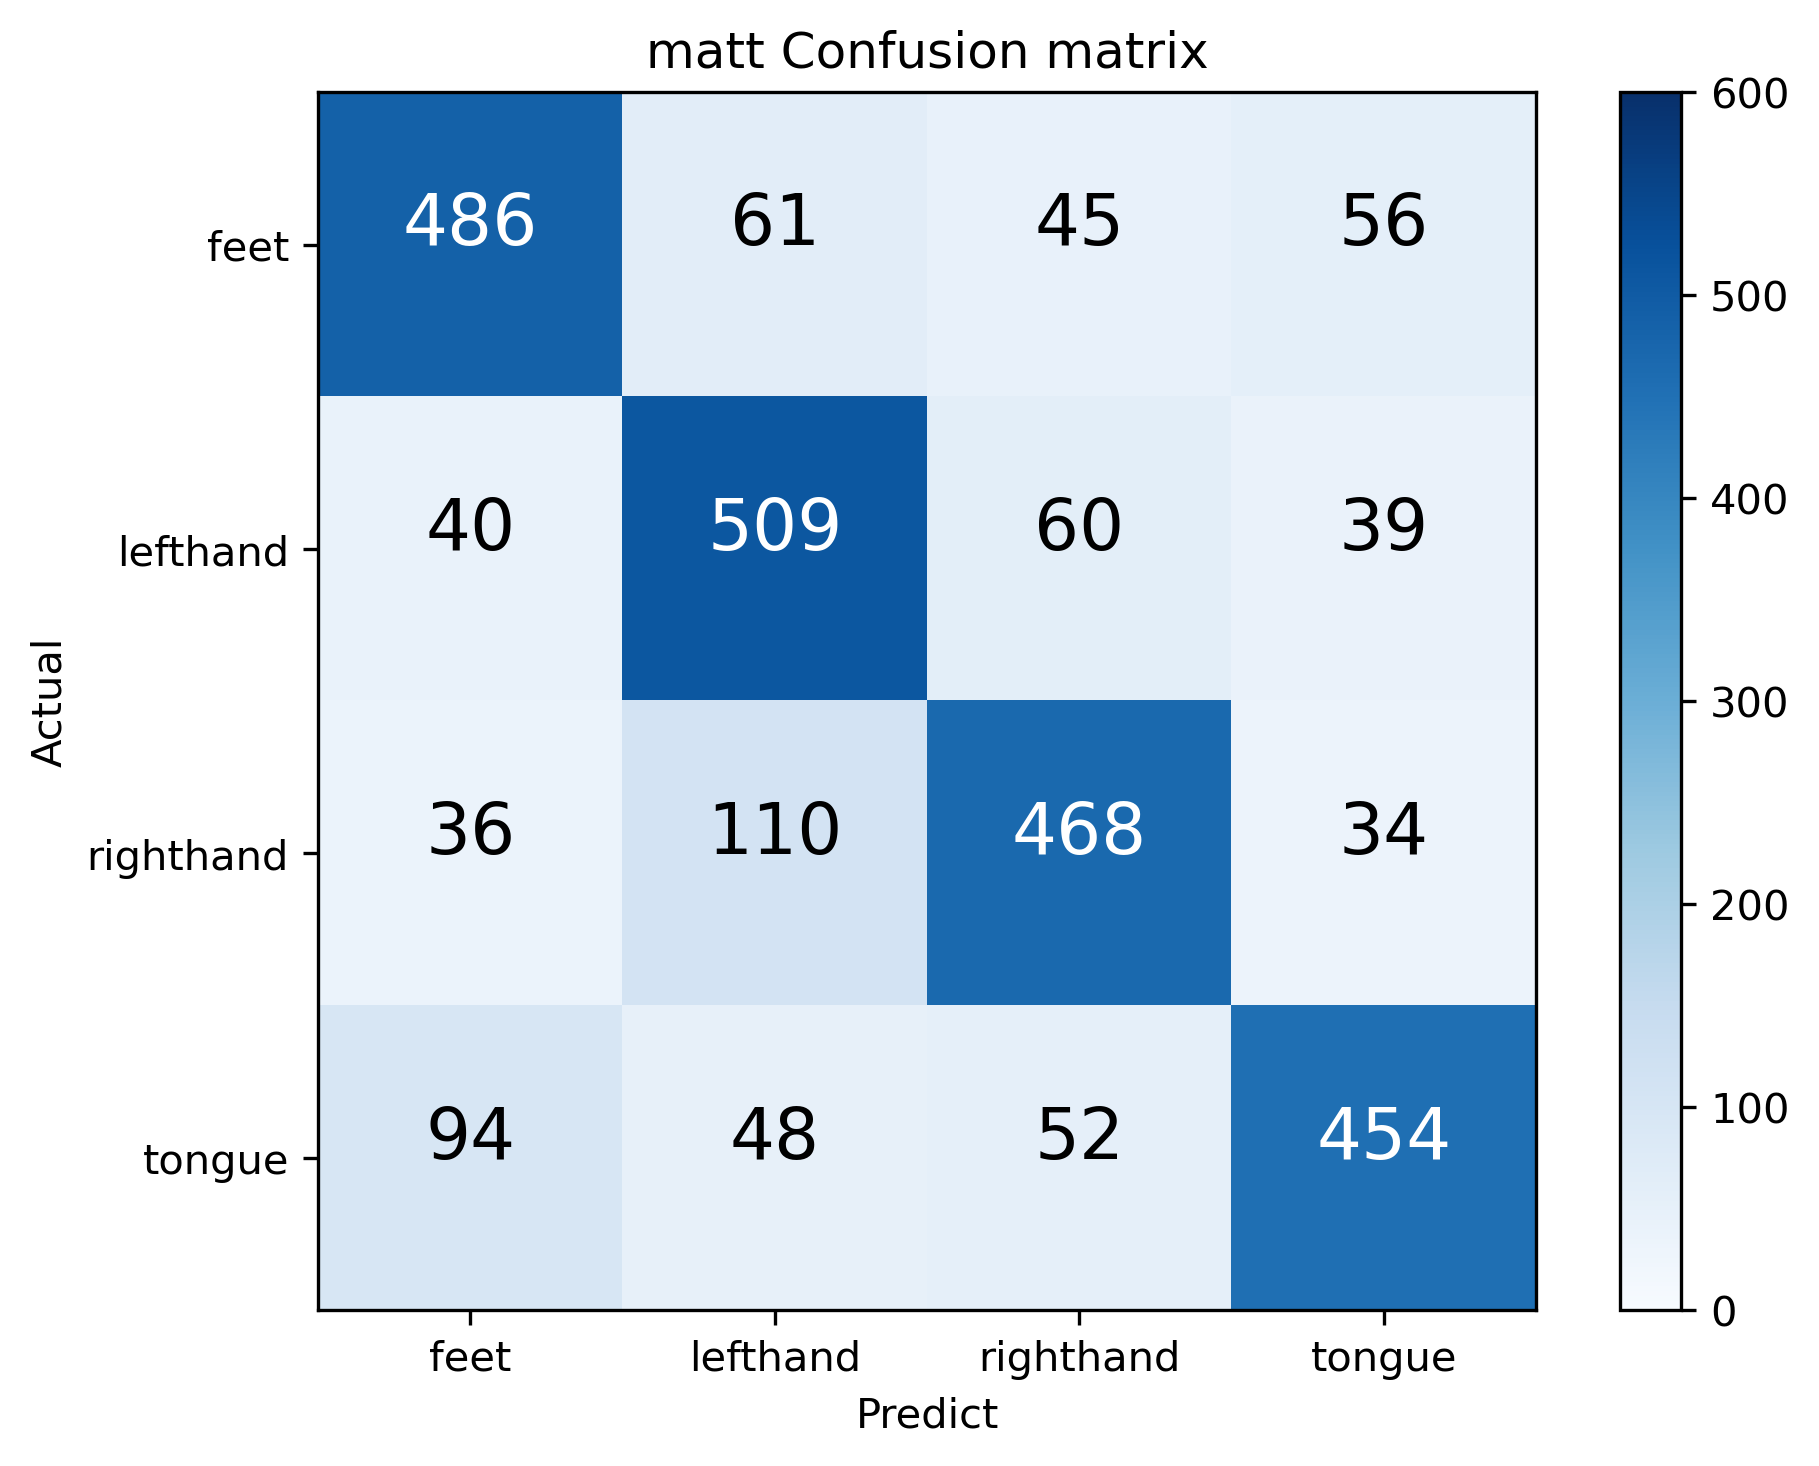

In [56]:

for model in summatrixs_all.keys():
    cmforplot = pycm.ConfusionMatrix(matrix=summatrixs_all[model])
    plt.figure(dpi=300)
    plot_confusion_matrix(cmforplot, title=model+' Confusion matrix')